# AQUASPECT — Proof of Concept
**Arab Youth Space Hackathon 813 | Theme 6: Water Quality & Inland/Coastal Water Intelligence**

This notebook demonstrates a reproducible pipeline using Planet Tanager hyperspectral imagery (El Gouna) and a 12-month Sentinel-2 temporal baseline (Lake Manzala).

> **Validation note:** No concurrent in-situ measurements are available. All indices are dimensionless proxies. Anomalies are statistical deviations from a historical baseline — not confirmed pollution or algal bloom events.


In [ ]:
import os, sys, warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path("c:/Users/wasfy/Downloads/AQUASPECT")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from aquaspect import preprocessing, indices, detection, visualization

DATA_DIR      = PROJECT_ROOT / "data" / "sample_input"
RESULTS_MAPS     = PROJECT_ROOT / "results" / "maps"
RESULTS_FIGURES  = PROJECT_ROOT / "results" / "figures"


---
## Part 1 — El Gouna Hyperspectral Analysis (Planet Tanager)
**Scene ID:** `20250926_092059_95_4001` · **Date:** 2025-09-26 · **Bands:** 426 · **Range:** 376–2499 nm


In [ ]:
TANAGER_FILE = DATA_DIR / "20250926_092059_95_4001_ortho_sr_hdf5.h5"

valid_mask, qa_stats = preprocessing.build_qa_mask(str(TANAGER_FILE))
print("QA Statistics:")
for k, v in qa_stats.items():
    print(f"  {k}: {v}")

with h5py.File(TANAGER_FILE, "r") as f:
    sr          = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]
    wavelengths = sr.attrs["wavelengths"][:]
    print(f"\nArray shape: {sr.shape}  |  {wavelengths[0]:.1f} – {wavelengths[-1]:.1f} nm")

    target_nms  = [443, 560, 665, 708, 800, 860]
    band_idx    = {t: int(np.argmin(np.abs(wavelengths - t))) for t in target_nms}
    for t, i in band_idx.items():
        print(f"  {t} nm target -> {wavelengths[i]:.1f} nm (band {i})")

    def load_b(nm):
        arr = sr[band_idx[nm], :, :].astype(np.float32) * 1e-4
        arr[~valid_mask] = np.nan
        arr[(arr < 0) | (arr > 1)] = np.nan
        return arr

    b_green, b_red, b_rededge, b_nir2 = load_b(560), load_b(665), load_b(708), load_b(860)

ndwi_arr   = indices.ndwi(b_green, b_nir2)
wm_raw     = indices.water_mask(ndwi_arr, threshold=0.0)
water_mask, water_stats = detection.apply_water_mask(wm_raw & valid_mask, min_pixels=100, pixel_area_m2=900)
print(f"\nWater area: {water_stats['estimated_area_km2']:.2f} km²  ({water_stats['retained_water_pixels']:,} px)")

ndci_arr = indices.ndci(b_rededge, b_red)
turb_arr = indices.turbidity_proxy(b_red, b_green)
tv = turb_arr[water_mask]; tv = tv[~np.isnan(tv)]
print(f"Turbidity proxy (Red/Green): mean={np.mean(tv):.4f}  max={np.max(tv):.4f}")


### Map 1 — Water Mask (NDWI threshold = 0.0)

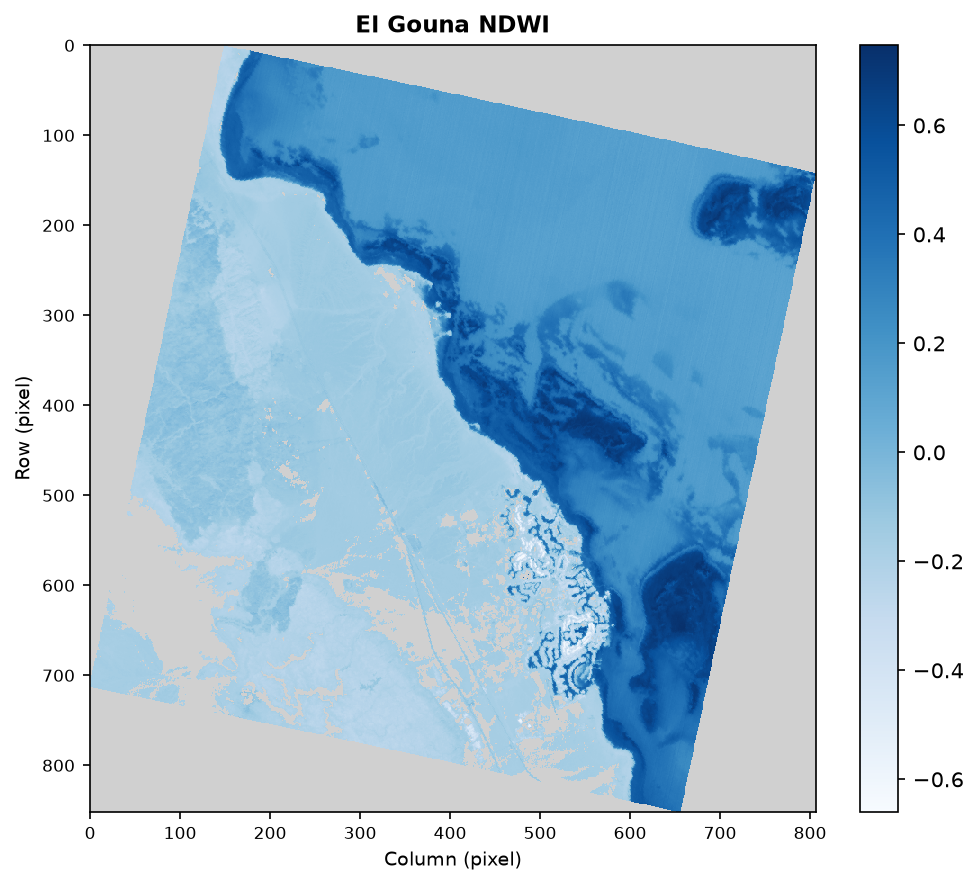


### Map 2 — NDCI Chlorophyll Screening

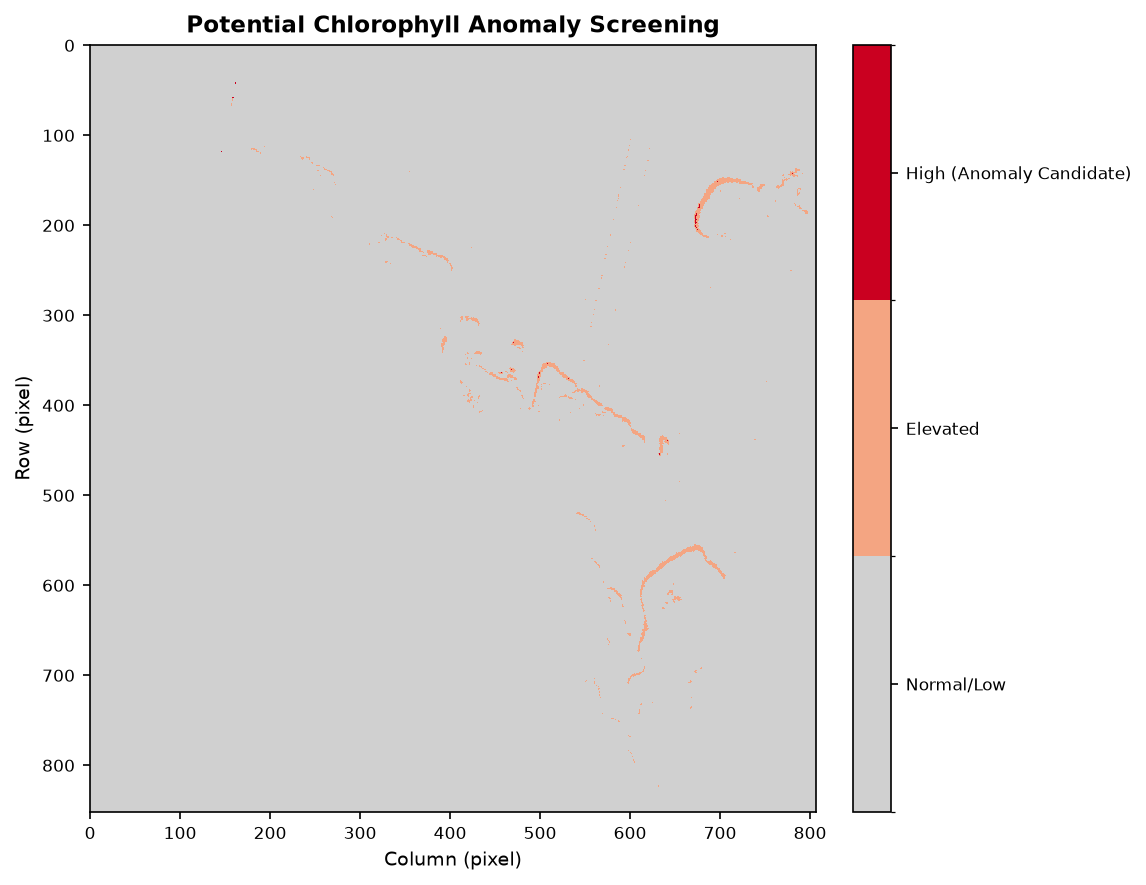


### Map 3 — Turbidity Proxy (Red/Green Ratio)

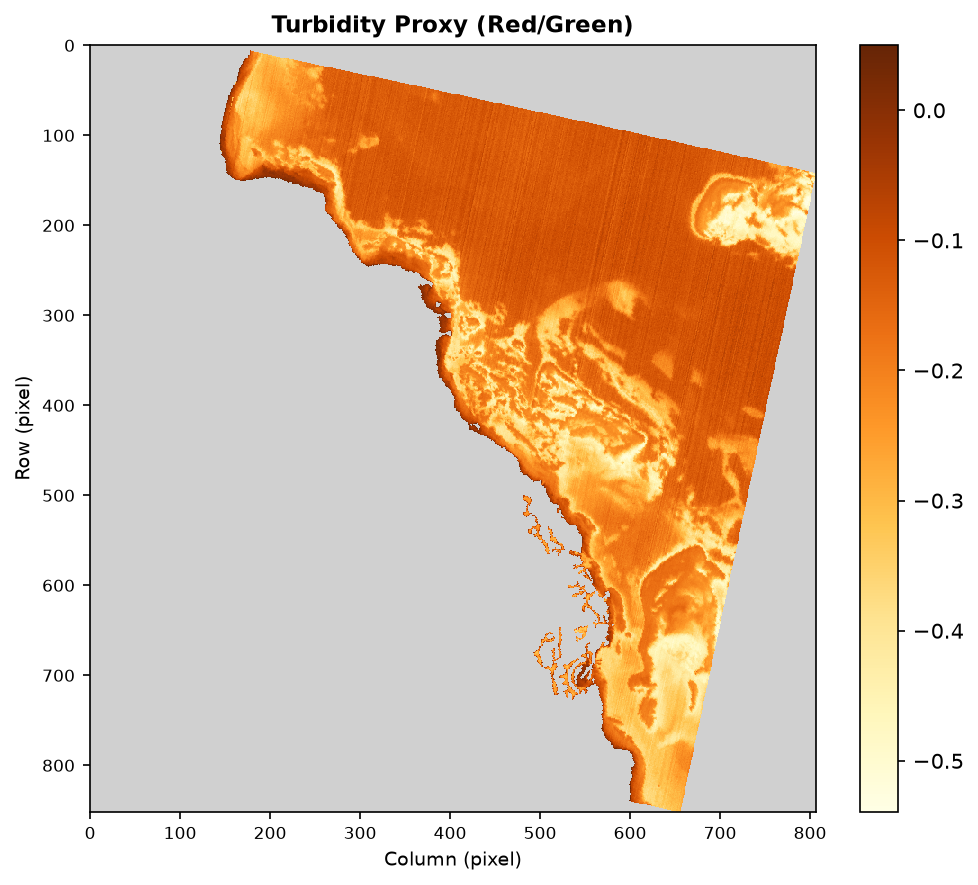


### Figure 1 — Hyperspectral Spectral Signature (426 bands, 376–2499 nm)

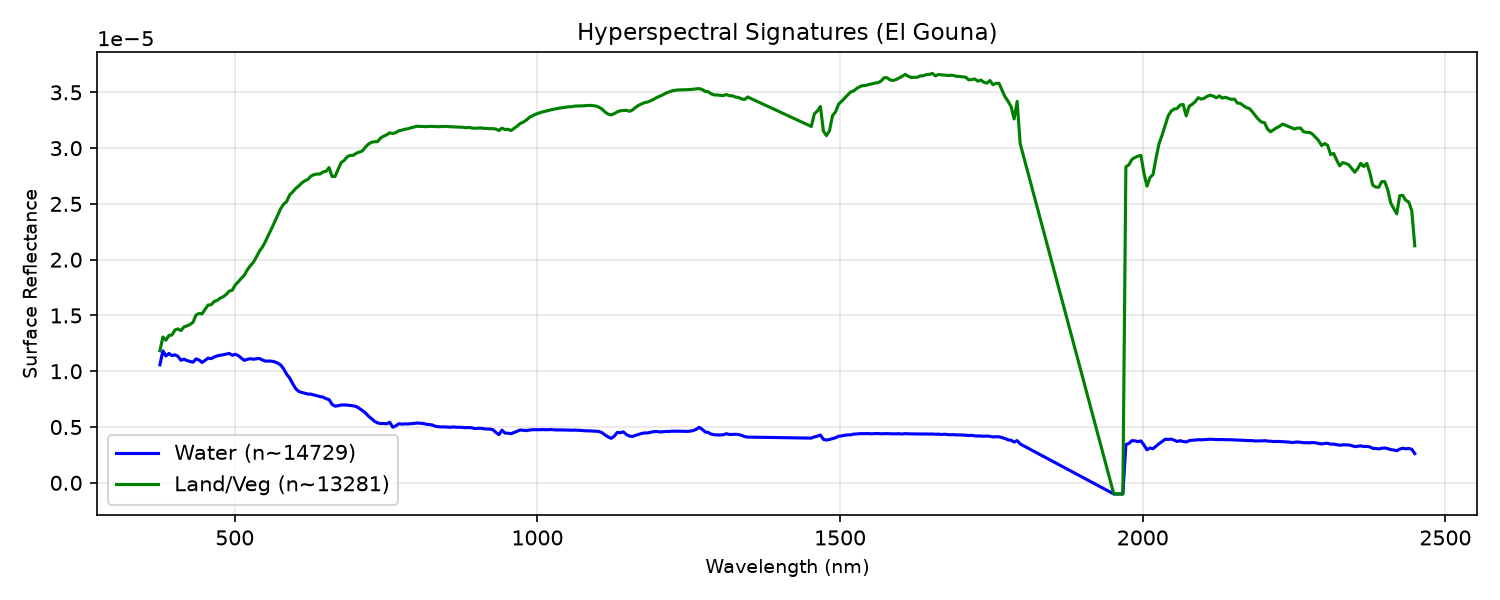


---
## Part 2 — Lake Manzala Temporal Baseline (Sentinel-2 L2A)
8 distinct scenes · June 2024 – May 2025 · Turbidity proxy Z-score anomaly detection


In [ ]:
s2_metrics = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "manzala_temporal_metrics.csv")
display(s2_metrics)


### Figure 2 — 12-Month Turbidity Proxy Baseline (Sentinel-2 L2A)

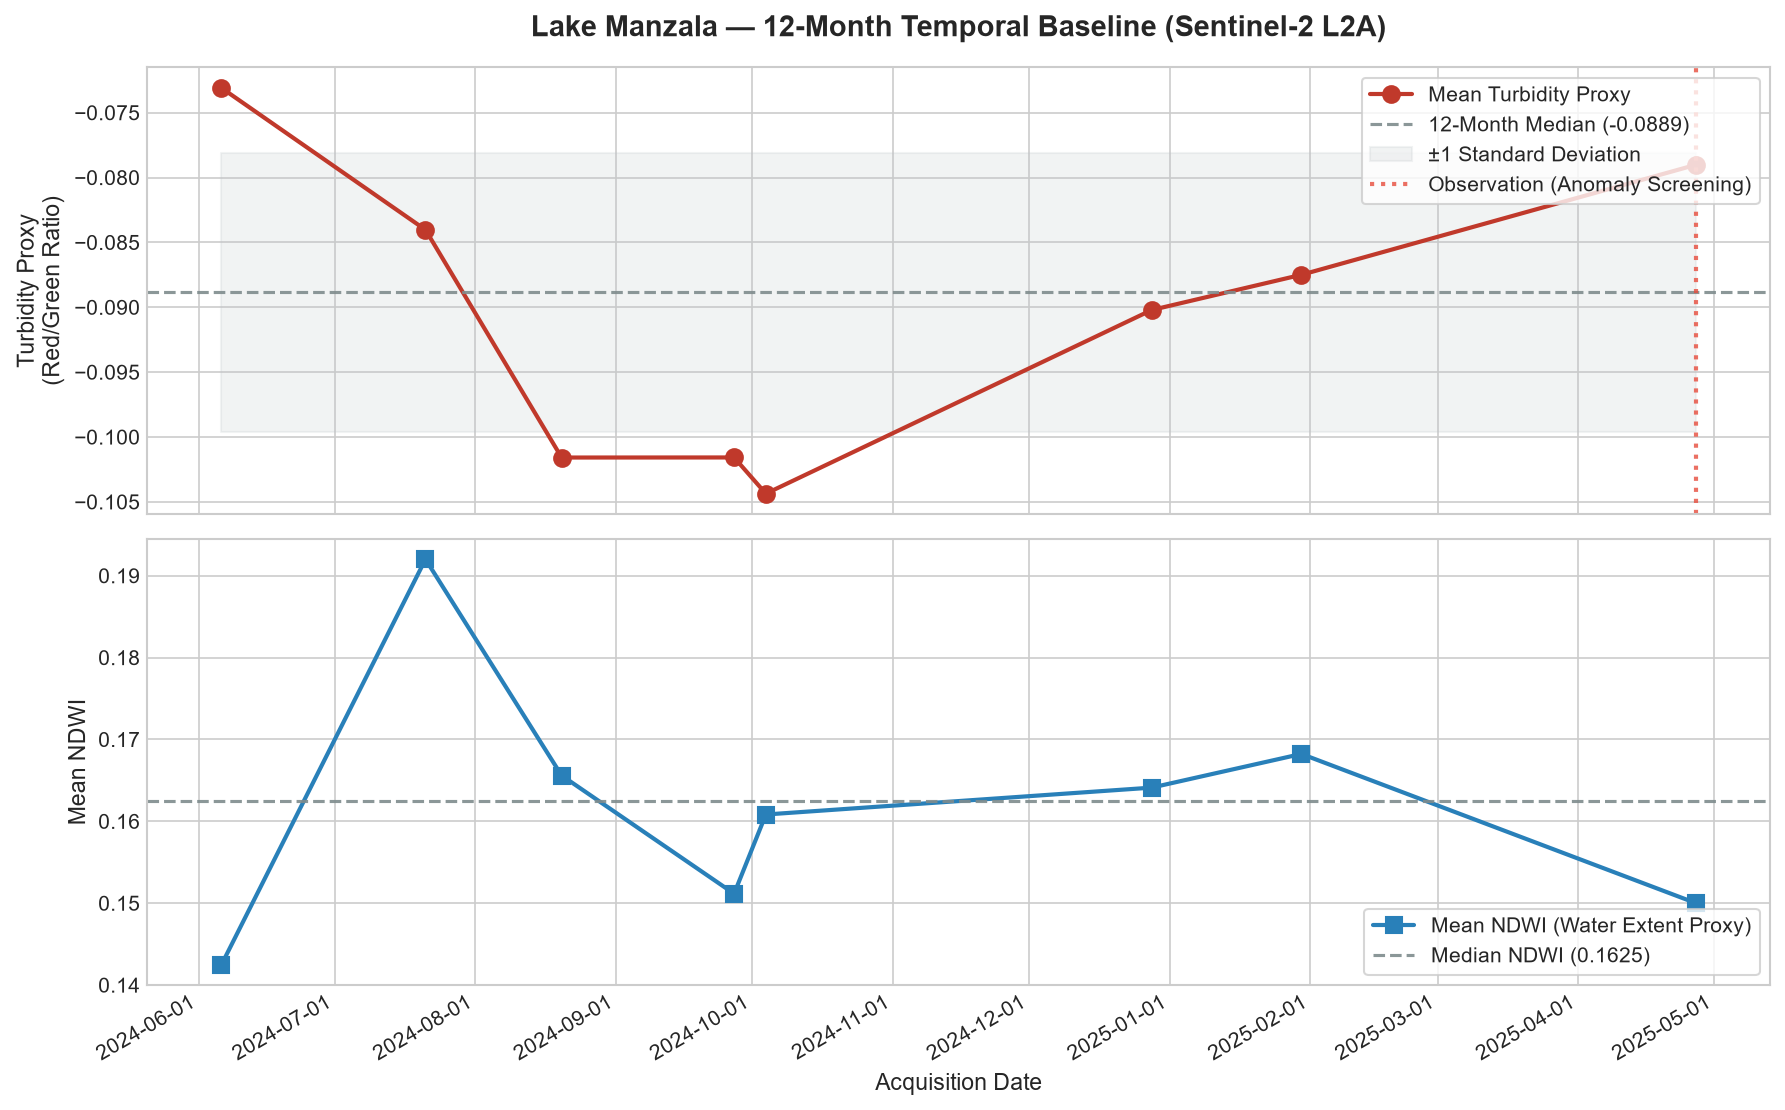


In [ ]:
anomaly = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "manzala_anomaly_summary.csv")
total_water = s2_metrics.iloc[-1]['water_pixels']
extreme_px  = anomaly.iloc[0]['anomaly_extreme_px']

print("Anomaly Detection Results (Z-Score method):")
display(anomaly)

print(f"\nOn {anomaly.iloc[0]['reference_date']}:")
print(f"  {extreme_px:,} pixels ({extreme_px/total_water:.1%}) exceed Z = 3.0 vs the 12-month baseline.")
print("  This constitutes a statistically extreme deviation warranting field verification.")
